# The Chosen Dataset
- We chose a dataset from the Stack Overflow Developer Survey, which contains information about developers worldwide such as experience, education, job roles, technologies used, and salaries. It is used to analyze trends in the software engineering field and understand factors affecting developers’ careers.

- Source: https://survey.stackoverflow.co/


---

# Task 1: Exploratory Data Analysis & Visualization

### Imports

In [1]:
import numpy as np
import pandas as pd
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import skfuzzy as fuzz

from skfuzzy import control as ctrl

import random

### Read data

In [2]:
df = pd.read_csv('stackoverflow_survey.csv')

C:\Users\lenovo\AppData\Local\Temp\ipykernel_40464\1236879090.py:1: DtypeWarning: Columns (0: ResponseId, 1: DevEnvHaveEntry, 2: SOTagsHaveEntry, 3: SOTagsWant Entry, 4: CommPlatformHaveEntr, 5: CommPlatformWantEntr, 6: AIAgentOrchestration, 7: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('stackoverflow_survey.csv')


- Lets explore the data

In [3]:
pd.set_option('display.max_columns', None)
df.sample(20)

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,Industry,AIThreat,NewRole,ToolCountWork,ToolCountPersonal,Country,Currency,CompTotal,LanguageChoice,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,LanguagesHaveEntry,LanguagesWantEntry,DevEnvsChoice,DevEnvsHaveWorkedWith,DevEnvsWantToWorkWith,DevEnvsAdmired,DevEnvHaveEntry,DevEnvWantEntry,SOTagsHaveWorkedWith,SOTagsWantToWorkWith,SOTagsAdmired,SOTagsHaveEntry,SOTagsWant Entry,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,CommPlatformHaveWorkedWith,CommPlatformWantToWorkWith,CommPlatformAdmired,CommPlatformHaveEntr,CommPlatformWantEntr,AIModelsChoice,AIModelsHaveWorkedWith,AIModelsWantToWorkWith,AIModelsAdmired,AIModelsHaveEntry,AIModelsWantEntry,SOAccount,SOVisitFreq,SODuration,SOPartFreq,SO_Dev_Content,SOComm,SOFriction,AISelect,AISent,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
34676,34672,I am a developer by profession,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,NaN,10.0,"Yes, I am not new to coding but am learning ne...",Books / Physical media;Stack Overflow or Stack...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3102,3103,I am a developer by profession,55-64 years old,Some college/university study without earning ...,Employed,Engaged in paid work (less than 10 hours per w...,39.0,"Yes, I am not new to coding but am learning ne...",Books / Physical media;Technical documentation...,"Yes, I learned how to use AI-enabled tools for...",NaN,45.0,"Developer, back-end",100 to 499 employees,Individual contributor,Remote,"Yes, I endorsed a tool that was open-source an...",Work,4.0,6.0,3.0,1.0,2.0,8.0,9.0,7.0,5.0,10.0,NaN,Other:,No,I have neither consider or transitioned into a...,NaN,NaN,United States of America,USD United States dollar,NaN,Yes,Bash/Shell (all shells);HTML/CSS;JavaScript;Pe...,Bash/Shell (all shells);HTML/CSS;Python;SQL,Bash/Shell (all shells);HTML/CSS;Python;SQL,NaN,NaN,Yes,Neovim;Vim,Neovim;Vim,Neovim;Vim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MacOS,MacOS,GitHub;Wikis,GitHub,GitHub,Stack Overflow;Stack Exchange;Reddit;Slack (pu...,Stack Overflow;Stack Exchange;Reddit,Stack Overflow;Stack Exchange;Reddit,NaN,NaN,Yes,NaN,NaN,NaN,NaN,NaN,Yes,A few times per week,"More than 15 years, or since Stack Overflow st...",A few times per week,Long-form articles;Lists of recommendations (t...,Neutral,"Rarely, almost never","Yes, I use AI tools monthly or infrequently",Favorable,NaN,NaN,NaN,NaN,I am concerned about the accuracy of the infor...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other (please specify):,NaN,NaN,8.0
26919,26915,I am a developer by profession,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,7.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",Videos (not associated with specific online co...,9.0,"Developer, back-end",100 to 499 employees,Individua

In [4]:
df.dtypes

ResponseId              object
MainBranch                 str
Age                        str
EdLevel                    str
Employment                 str
                        ...   
AIAgentExtWrite            str
AIHuman                    str
AIOpen                     str
ConvertedCompYearly    float64
JobSat                 float64
Length: 98, dtype: object

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49196 entries, 0 to 49195
Data columns (total 98 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ResponseId                          49195 non-null  object 
 1   MainBranch                          49190 non-null  str    
 2   Age                                 49190 non-null  str    
 3   EdLevel                             48148 non-null  str    
 4   Employment                          48338 non-null  str    
 5   EmploymentAddl                      44874 non-null  str    
 6   WorkExp                             42892 non-null  float64
 7   LearnCodeChoose                     46857 non-null  str    
 8   LearnCode                           33556 non-null  str    
 9   LearnCodeAI                         45200 non-null  str    
 10  AILearnHow                          28256 non-null  str    
 11  YearsCode                           43041 non-null  

In [6]:
df.describe()

,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,ToolCountWork,ToolCountPersonal,CompTotal,ConvertedCompYearly,JobSat
count,42892.000000,43041.000000,35974.000000,35974.000000,35974.000000,35974.000000,35974.000000,35974.000000,35974.000000,35974.000000,35974.000000,35974.000000,27610.000000,25581.000000,2.486500e+04,2.394600e+04,26669.000000
mean,13.367551,16.571037,7.867265,4.104214,4.110246,5.677990,4.119308,5.225913,6.477512,4.370879,4.431506,9.854200,17.735168,8.545757,2.234287e+70,1.017630e+05,7.201845
std,10.800199,11.787691,2.397408,2.275852,2.329564,2.397806,2.437932,2.801046,2.331380,2.357080,2.620773,1.975599,269.815015,44.665602,3.523167e+72,4.617665e+05,1.997209
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000e+00,1.000000e+00,0.000000
25%,5.000000,8.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,2.000000,2.000000,10.000000,4.000000,3.000000,5.500000e+04,3.817100e+04,6.000000
50%,10.000000,14.000000,9.000000,4.000000,4.000000,6.000000,4.000000,5.000000,7.000000,4.000000,4.000000,10.000000,6.000000,5.000000,1.050000e+05,7.532000e+04,8.000000
75%,20.000000,24.000000,9.000000,6.000000,6.000000,8.000000,6.000000,8.000000,8.000000,6.000000,7.000000,10.000000,10.000000,7.000000,2.400000e+05,1.205980e+05,8.000000
max,100.000000,100.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,10000.000000,1000.000000,5.555556e+74,5.000000e+07,10.000000


### Comparison of Tech Salaries by Job Title
- The bar chart below compares the average annual salaries for different types of developers and tech professionals. It highlights which roles currently command the highest pay in the industry, ranging from entry-level students to executive leadership.

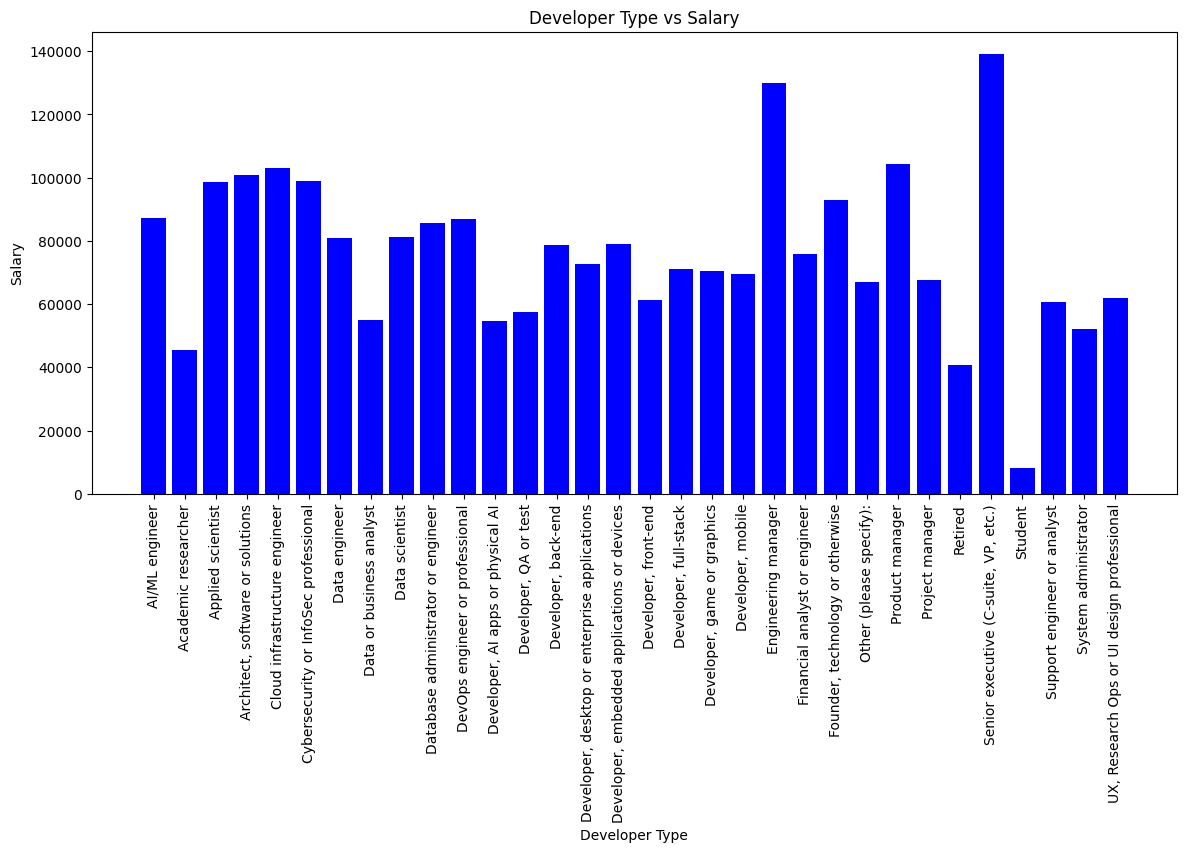

In [7]:
plt.figure(figsize=(14,6))
salaryByType = df.groupby('DevType')['ConvertedCompYearly'].median()
plt.bar(salaryByType.index, salaryByType.values, color="blue")
plt.title("Developer Type vs Salary")
plt.xlabel("Developer Type")
plt.xticks(rotation=90)
plt.ylabel("Salary")
plt.show()

- The data shows that moving into leadership or specialized infrastructure roles is the most effective way to increase earning potential in the tech world.

### Age Distribution
- This pie chart shows the age breakdown of the people surveyed. It helps us understand which age groups are most active or well-represented in this dataset.

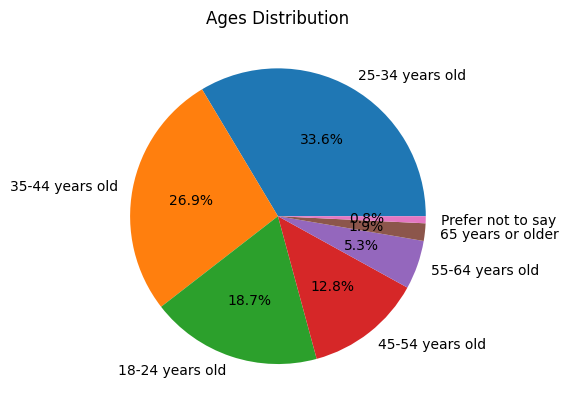

In [8]:
plt.pie(df["Age"].value_counts(), labels=df["Age"].value_counts().index, autopct="%1.1f%%")
plt.title("Ages Distribution")
plt.show()

- The data is heavily skewed toward young to mid-career professionals, with very few respondents over the age of 65.

### Job Satisfaction Distribution
- This histogram displays how employees rate their job satisfaction on a scale of 0 to 10. It allows us to see the overall sentiment of the workforce and whether most employees are happy or dissatisfied.

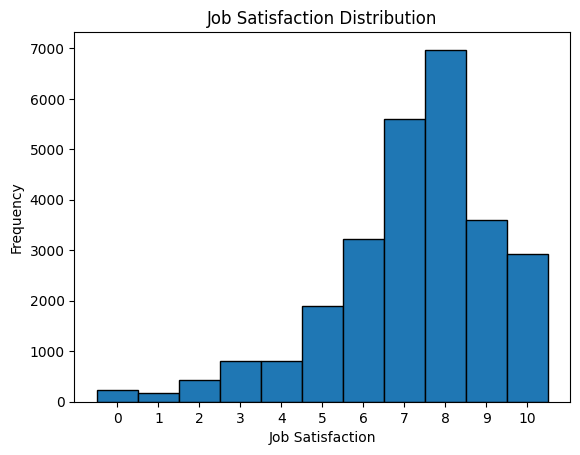

In [9]:
plt.hist(df["JobSat"], bins=np.arange(-0.5, 11.5, 1), edgecolor='black')
plt.title("Job Satisfaction Distribution")
plt.xlabel("Job Satisfaction")
plt.ylabel("Frequency")
plt.xticks(range(11))
plt.show()

- Overall, job satisfaction is high, with most employees rating their experience in the 7 to 9 range (Left-Skewed).

### Remote Work Distribution
- This pie chart illustrates the distribution of work environments among the surveyed professionals. It breaks down how many people work fully remotely, in-person, or under various hybrid models, providing insight into modern workplace flexibility.

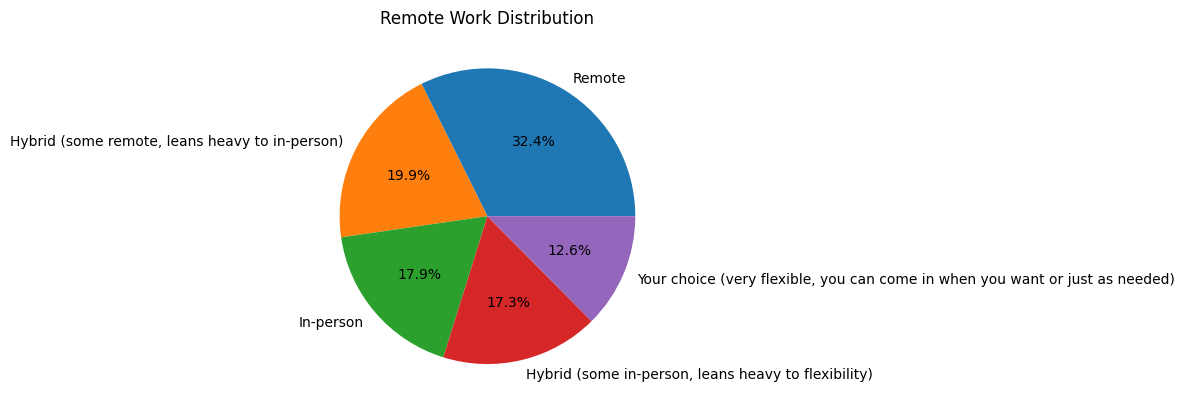

In [10]:
plt.pie(df["RemoteWork"].value_counts(), labels=df["RemoteWork"].value_counts().index, autopct="%1.1f%%")
plt.title("Remote Work Distribution")
plt.show()

- The data clearly shows a shift away from traditional office-only work, with over 80% of respondents having at least some level of remote flexibility.

### Yearly Salary Distribution and Outliers
- This box plot visualizes the spread of annual compensation. While box plots are designed to show the median and quartiles

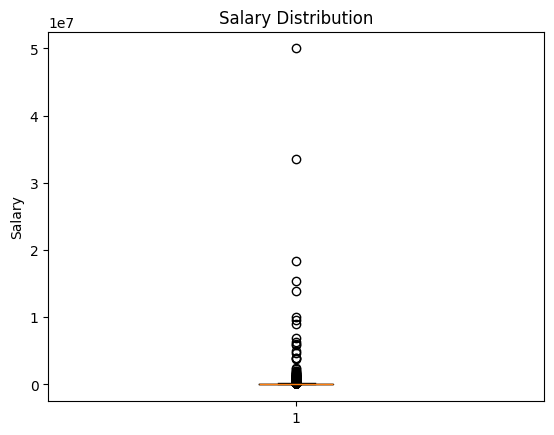

In [11]:
plt.boxplot(df["ConvertedCompYearly"].dropna())
plt.title("Salary Distribution")
plt.ylabel("Salary")
plt.show()

- The plot shows that the salary data is heavily skewed by a few massive values. To see the "typical" salary more clearly, these outliers would likely need to be filtered out or the axis would need to be limited.

### Distribution of Company Sizes
- This pie chart breaks down the sizes of the organizations where respondents work. It provides a look at the diversity of the workplace landscape, from solo freelancers to massive global corporations.

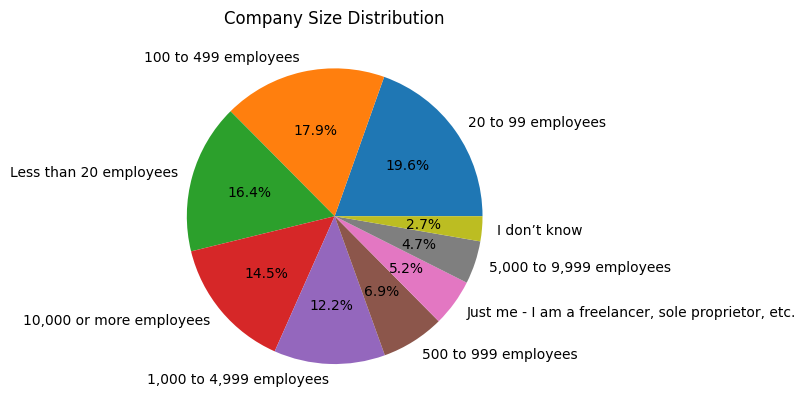

In [12]:
plt.pie(df["OrgSize"].value_counts(), labels=df["OrgSize"].value_counts().index, autopct="%1.1f%%")
plt.title("Company Size Distribution")
plt.show()

- The data shows a very balanced distribution, suggesting that developers are spread relatively evenly across startups, mid-sized firms, and large enterprises.

---

# Task 2: Data Preprocessing 

- Select most important features from dataset

In [13]:
df = df[['Age', 'EdLevel', 'Employment', 'WorkExp',
        'LearnCode', 'YearsCode', 'DevType', 'OrgSize',
        'RemoteWork', 'Industry', 'AIThreat', 'NewRole',
        'AISelect', 'AISent', 'LanguageAdmired', 
        'ConvertedCompYearly', 'JobSat']]

# LearnCode, YearsCode, LanguageAdmired ==> Tech Score (Bonus)
# AIThreat, newRule, aiSelect, AiSent ==> Ai Score (Bonus)

### Remove duplicate rows

- Remove 2,926 duplicate rows from the dataset.

In [14]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

2926
0


### Handle missing values

In [15]:
df.isnull().sum()

Age                        1
EdLevel                  173
Employment                 8
WorkExp                 4307
LearnCode              12756
YearsCode               3247
DevType                 2609
OrgSize                12097
RemoteWork             12495
Industry               12629
AIThreat               10194
NewRole                10745
AISelect               12551
AISent                 12804
LanguageAdmired        22801
ConvertedCompYearly    22324
JobSat                 19601
dtype: int64

- We start by removing rows that contain missing values in critical columns to ensure the dataset remains reliable for analysis and modeling.

In [16]:
df.dropna(subset=['LanguageAdmired', 'AISelect', 'AISent', 'AIThreat', 'NewRole', 'ConvertedCompYearly', 'YearsCode', 'LearnCode', 'JobSat'], axis=0, inplace=True)

- For numerical data, missing values are filled using the median because it is not affected by extreme values (outliers).

In [17]:
num_cols = ['WorkExp']

for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

For categorical features, missing values are filled using the mode, since it preserves the most common category.

In [18]:
cat_cols = ['OrgSize', 'RemoteWork', 'Industry' , 'WorkExp',  'EdLevel']

for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

In [19]:
df.isnull().sum()

Age                    0
EdLevel                0
Employment             0
WorkExp                0
LearnCode              0
YearsCode              0
DevType                0
OrgSize                0
RemoteWork             0
Industry               0
AIThreat               0
NewRole                0
AISelect               0
AISent                 0
LanguageAdmired        0
ConvertedCompYearly    0
JobSat                 0
dtype: int64

### Detecting and treating outliers

We detected outliers in the ConvertedCompYearly column using the IQR method. This method helps identify extreme values that are far from the normal range of the data.

IQR outliers in ConvertedCompYearly: 434


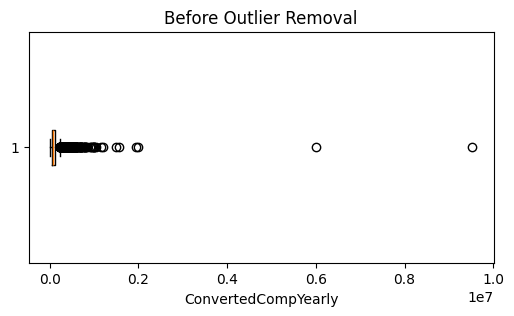

Remaining rows after trimming: 9752


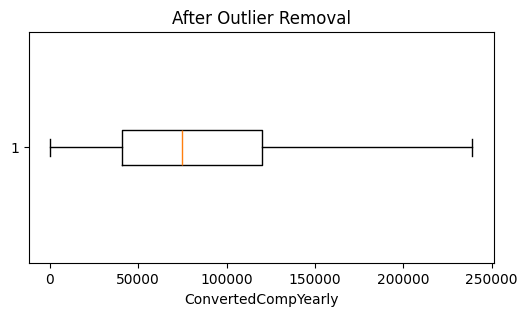

In [20]:
col = "ConvertedCompYearly"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print(f'IQR outliers in {col}: {len(outliers_iqr)}')

# Before plot
plt.figure(figsize=(6, 3))
plt.boxplot(df[col], vert=False)
plt.title('Before Outlier Removal')
plt.xlabel(col)
plt.show()

# Remove outliers properly

df[col] = df[col].clip(lower_bound, upper_bound)

print(f"Remaining rows after trimming: {len(df)}")

# After plot
plt.figure(figsize=(6, 3))
plt.boxplot(df[col], vert=False)
plt.title('After Outlier Removal')
plt.xlabel(col)
plt.show()

### Encoding categorical features

**Label Encoding**

- We used Label Encoding because these features are ordinal and have a natural order.

In [21]:
for col in ['Age', 'EdLevel', 'OrgSize', 'AIThreat', 'RemoteWork']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

**One-Hot Encoding**

- We used One-Hot Encoding because these features are nominal categories with no meaningful order.
- And for LearnCode, we used a multi-label one-hot approach because each row can contain multiple values separated by ;. This allows us to properly represent all learning sources without losing information.

In [22]:
learncode_encoded = df['LearnCode'].str.get_dummies(sep=';')
learncode_encoded.columns = [f"LearnCode_{col.strip()}" for col in learncode_encoded.columns]
df = pd.concat([df.drop(columns=['LearnCode']), learncode_encoded], axis=1)

one_hot_cols = ['Employment', 'DevType', 'Industry', 'NewRole', 'AISelect', 'AISent', 'LanguageAdmired']
df = pd.get_dummies(df, columns=one_hot_cols)

### Feature scaling

**MinMax Scaler**

- We applied scaling to bring all values into the same range, And we used Min-Max Scaling because it converts values into a fixed range between 0 and 1. This makes the data easier to compare and works well.

In [23]:
for col in ['WorkExp', 'YearsCode', 'ConvertedCompYearly']:
    std_scaler = MinMaxScaler()
    df[col] = std_scaler.fit_transform(df[[col]])

### Dimensionality Reduction

We used PCA to reduce multiple related features into a single score while keeping most of the important information and after creating the new scores, we removed the original columns to reduce dimensionality.

**AI Score**

In [24]:
print([col for col in df.columns if "AISelect" in col])
print([col for col in df.columns if "AISent" in col])
print([col for col in df.columns if "NewRole" in col])

["AISelect_No, and I don't plan to", 'AISelect_No, but I plan to soon', 'AISelect_Yes, I use AI tools daily', 'AISelect_Yes, I use AI tools monthly or infrequently', 'AISelect_Yes, I use AI tools weekly']
['AISent_Favorable', 'AISent_Indifferent', 'AISent_Unfavorable', 'AISent_Unsure', 'AISent_Very favorable', 'AISent_Very unfavorable']
['NewRole_I have neither consider or transitioned into a new career or industry', 'NewRole_I have somewhat considered changing my career and/or the industry I work in', 'NewRole_I have strongly considered changing my career and/or the industry I work in', 'NewRole_I have transitioned into a new career and/or industry involuntarily', 'NewRole_I have transitioned into a new career and/or industry voluntarily']


In [25]:
ai_select_cols = [col for col in df.columns if col.startswith('AISelect_')]
ai_sent_cols = [col for col in df.columns if col.startswith('AISent_')]
new_role_cols = [col for col in df.columns if col.startswith('NewRole_')]

ai_cols = ai_select_cols + ai_sent_cols + new_role_cols + ['AIThreat']

ai_features = df[ai_cols]

pca = PCA(n_components=1)
df['AIScore'] = pca.fit_transform(ai_features).ravel()

df.drop(columns=ai_cols, inplace=True)

**Tech Score**

In [26]:
print([col for col in df.columns if "LearnCode_" in col])
print([col for col in df.columns if "LanguageAdmired_" in col])

['LearnCode_AI CodeGen tools or AI-enabled apps', 'LearnCode_Blogs or podcasts', 'LearnCode_Books / Physical media', 'LearnCode_Coding Bootcamp', 'LearnCode_Colleague or on-the-job training', 'LearnCode_Games or coding challenges', 'LearnCode_Online Courses or Certification (includes all media types)', 'LearnCode_Other (please specify):', 'LearnCode_Other online resources (e.g. standard search, forum, online community)', 'LearnCode_School (i.e., University, College, etc)', 'LearnCode_Stack Overflow or Stack Exchange', 'LearnCode_Technical documentation (is generated for/by the tool or system)', 'LearnCode_Videos (not associated with specific online course or certification)']
['LanguageAdmired_Ada', 'LanguageAdmired_Ada;Assembly', 'LanguageAdmired_Ada;Assembly;Bash/Shell (all shells);C++;Go;JavaScript;PowerShell;Python;Rust;TypeScript', 'LanguageAdmired_Ada;Assembly;Bash/Shell (all shells);C;C#;C++;COBOL;Dart;Delphi;Elixir;Erlang;F#;Fortran;GDScript;Go;Groovy;HTML/CSS;Java;JavaScript;Ko

In [27]:
learncode_cols = [col for col in df.columns if col.startswith('LearnCode_')]
language_cols = [col for col in df.columns if col.startswith('LanguageAdmired_')]

tech_cols = learncode_cols + ['YearsCode'] + language_cols

tech_features = df[tech_cols]

pca = PCA(n_components=1)
df['TechScore'] = pca.fit_transform(tech_features).ravel()

df.drop(columns=tech_cols, inplace=True)

In [28]:
print(df.shape)
df_sample = df.sample(1)
df.drop(df_sample.index, inplace=True)

(9752, 60)


In [29]:
df.shape

(9751, 60)

---

# Task 3: K-Medoid Clustering

In [30]:
data=df.values

We test different values of k to choose the best number of clusters using two methods:
- Elbow Method (Inertia): to see when adding more clusters stops giving significant improvement.
- Silhouette Score: to measure how well the clusters are separated.

In [31]:
inertias = []
silhouette_scores = []
k_range = range(2, 20)

for k in k_range:
    model = KMedoids(n_clusters=k, metric="manhattan", init="random", random_state=42)
    model.fit(data)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(data, model.labels_))

- This plot shows how inertia changes as the number of clusters (k) increases, Each point represents a different k, The “elbow” point indicates the best k.

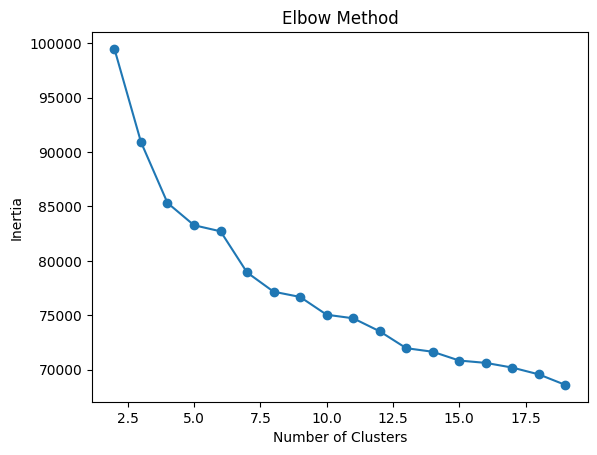

In [32]:
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

- This plot shows how the silhouette score changes with different values of k
- Each point represents a different number of clusters
- Higher values mean better separation between clusters
- We choose the k where the score is highest or stable at a good value

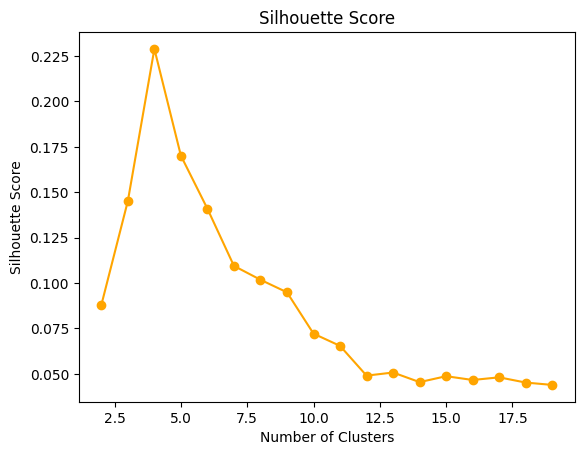

In [33]:
plt.plot(k_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

- selects the best value of k that gives the highest silhouette score.

In [34]:
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print("best k:", best_k)

best k: 4


In [35]:
Kmedoids_model = KMedoids(n_clusters=best_k, metric="manhattan", init="random", random_state=42)
Kmedoids_model.fit(data)

,n_clusters,4
,metric,'manhattan'
,method,'alternate'
,init,'random'
,max_iter,300
,random_state,42


In [36]:
centers = Kmedoids_model.medoid_indices_
print("centers: ", centers)

centers:  [3523 1919 7481 6246]


In [37]:
df['Cluster'] = Kmedoids_model.labels_

---

# Task 4: Hierarchical Clustering

- This code generates dendrograms for hierarchical clustering using different linkage methods (single, complete, average). It visualizes how data points are grouped and compares the clustering structure for each method.

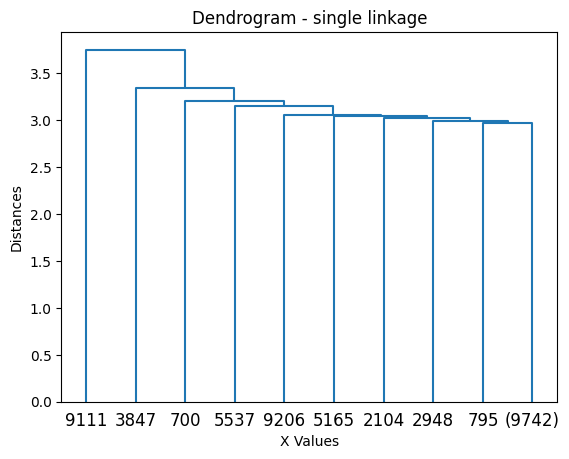

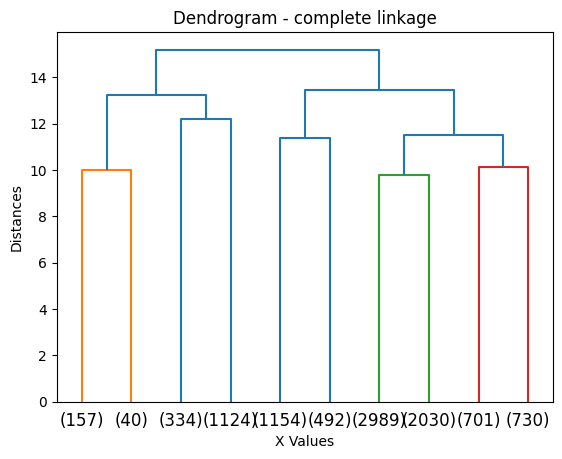

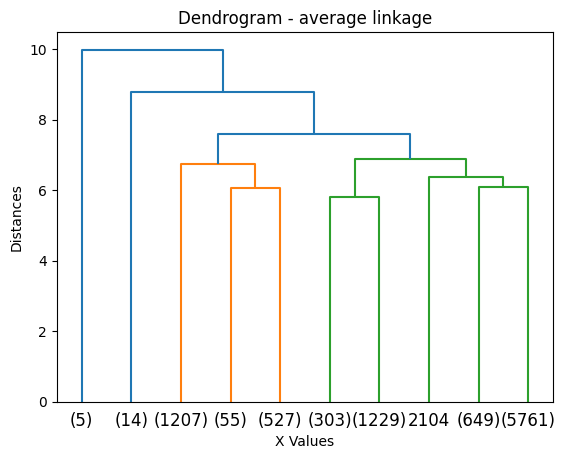

In [38]:
for method in ['single', 'complete', 'average']:
    dendrogram = sch.dendrogram(sch.linkage(data, method), truncate_mode='lastp', p=10)
    plt.title(f'Dendrogram - {method} linkage')
    plt.xlabel('X Values')
    plt.ylabel('Distances')
    plt.show()

- This code evaluates clustering performance for different numbers of clusters using Agglomerative Clustering. It computes the silhouette score for each k to help determine the optimal number of clusters.

In [39]:
linkages = ['single', 'complete', 'average']
k_range = range(2, 20)
all_scores = {linkage: [] for linkage in linkages}
best_score = -1
hbest_k = None
best_linkage = None

for linkage in linkages:
    for k in k_range:
        model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage=linkage)
        labels = model.fit_predict(data)
        score = silhouette_score(data, labels)
        all_scores[linkage].append(score)
        if score > best_score:
            best_score = score
            hbest_k = k
            best_linkage = linkage

- Plots the silhouette score for different numbers of clusters to evaluate hierarchical clustering performance and visualize the best choice of k. It then selects and prints the value of k that gives the highest silhouette score.

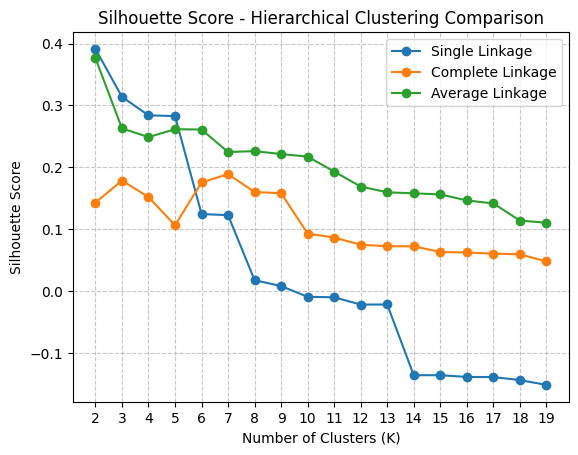

Best Linkage: single
Best K: 2
Highest Silhouette Score: 0.3914


In [40]:
for linkage in linkages:
    plt.plot(k_range, all_scores[linkage], marker='o', label=f"{linkage.capitalize()} Linkage")

plt.title('Silhouette Score - Hierarchical Clustering Comparison')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
print(f"Best Linkage: {best_linkage}")
print(f"Best K: {hbest_k}")
print(f"Highest Silhouette Score: {best_score:.4f}")

- This code applies Agglomerative Clustering using different linkage methods (single, complete, average) with the best number of clusters, then reduces the data to 2D using PCA and visualizes the resulting clusters.

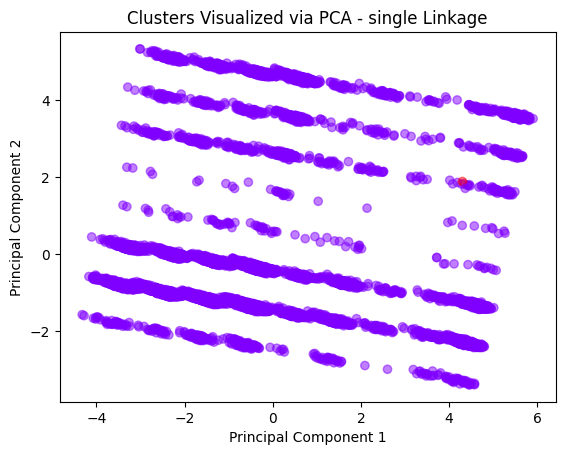

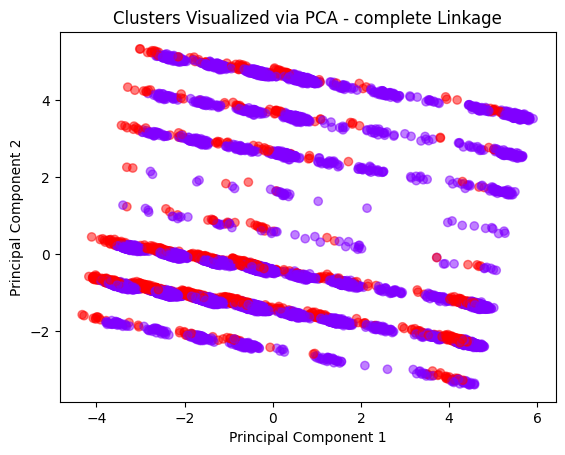

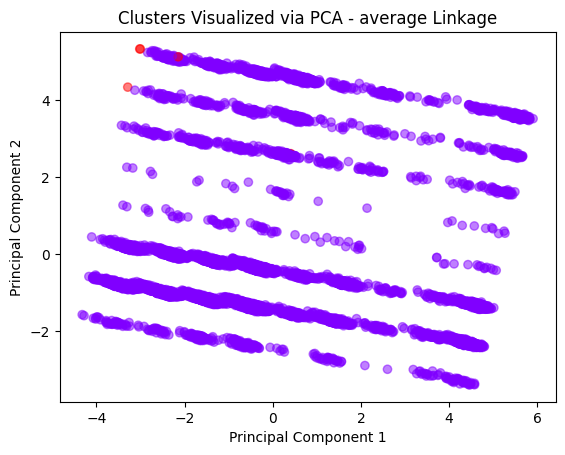

In [41]:
Hcluster = {}
Hlabels = {}

for method in ['single', 'complete', 'average']:
    Hcluster[method] = AgglomerativeClustering(n_clusters=hbest_k, metric='euclidean', linkage=method)
    Hlabels[method] = Hcluster[method].fit_predict(data)
    pca_2d = PCA(n_components=2)
    data_2d = pca_2d.fit_transform(data)

    plt.scatter(data_2d[:,0], data_2d[:,1], c=Hlabels[method], cmap='rainbow', alpha=0.5)
    plt.title(f'Clusters Visualized via PCA - {method} Linkage')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

---

# Task 5: Fuzzy Logic Inference System


- Checks how different numerical features are related to job satisfaction

Correlation with JobSat:
JobSat                 1.000000
Cluster                0.272678
ConvertedCompYearly    0.108205
WorkExp                0.104270
AIScore                0.031263
TechScore              0.007260
Name: JobSat, dtype: float64


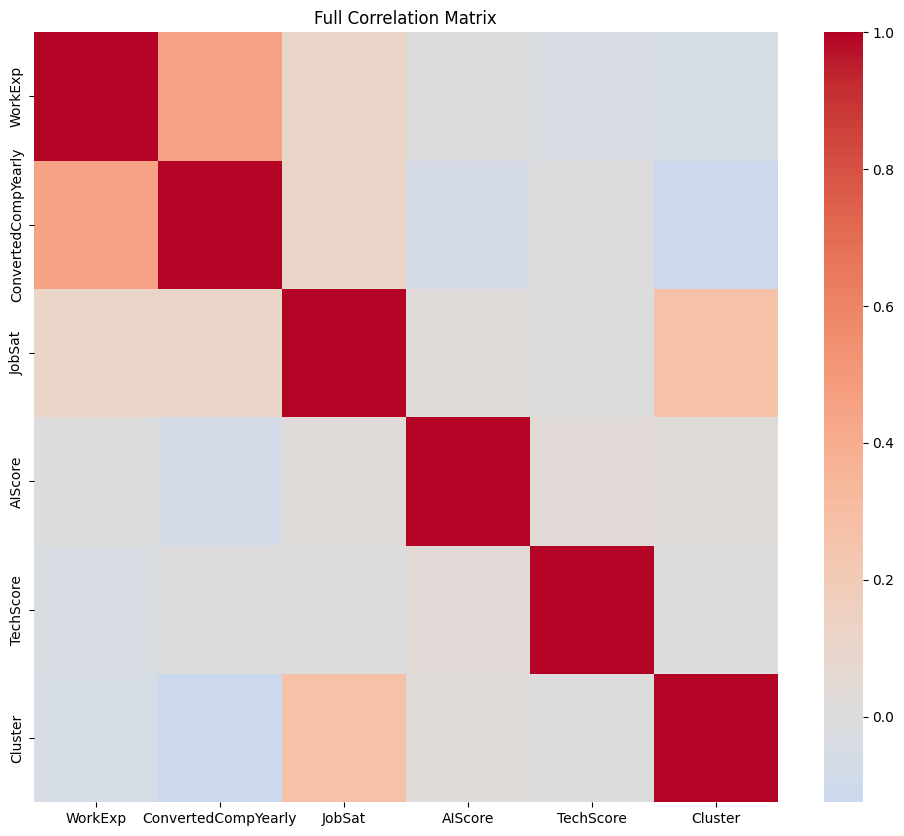

Feature importance (absolute correlation):
JobSat                 1.000000
Cluster                0.291407
WorkExp                0.096284
ConvertedCompYearly    0.086902
AIScore                0.042463
TechScore              0.005701
Name: JobSat, dtype: float64


In [42]:
df_corr = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = df_corr.corr(method='spearman')
job_corr = corr_matrix['JobSat'].sort_values(ascending=False)

print("Correlation with JobSat:")
print(job_corr)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Full Correlation Matrix")
plt.show()

importance = df_corr.corr()['JobSat'].abs().sort_values(ascending=False)

print("Feature importance (absolute correlation):")
print(importance)

### Antecedents

In [43]:
df.sample(20)

,Age,EdLevel,WorkExp,OrgSize,RemoteWork,ConvertedCompYearly,JobSat,Employment_Employed,Employment_I prefer not to say,"Employment_Independent contractor, freelancer, or self-employed",Employment_Not employed,Employment_Student,DevType_AI/ML engineer,DevType_Academic researcher,DevType_Applied scientist,"DevType_Architect, software or solutions",DevType_Cloud infrastructure engineer,DevType_Cybersecurity or InfoSec professional,DevType_Data engineer,DevType_Data or business analyst,DevType_Data scientist,DevType_Database administrator or engineer,DevType_DevOps engineer or professional,"DevType_Developer, AI apps or physical AI","DevType_Developer, QA or test","DevType_Developer, back-end","DevType_Developer, desktop or enterprise applications","DevType_Developer, embedded applications or devices","DevType_Developer, front-end","DevType_Developer, full-stack","DevType_Developer, game or graphics","DevType_Developer, mobile",DevType_Engineering manager,DevType_Financial analyst or engineer,"DevType_Founder, technology or otherwise",DevType_Other (please specify):,DevType_Product manager,DevType_Project manager,"DevType_Senior executive (C-suite, VP, etc.)",DevType_Student,DevType_Support engineer or analyst,DevType_System administrator,"DevType_UX, Research Ops or UI design professional",Industry_Banking/Financial Services,Industry_Computer Systems Design and Services,Industry_Energy,Industry_Fintech,Industry_Government,Industry_Healthcare,Industry_Higher Education,Industry_Insurance,"Industry_Internet, Telecomm or Information Services",Industry_Manufacturing,Industry_Media & Advertising Services,Industry_Other:,Industry_Retail and Consumer Services,Industry_Software Development,"Industry_Transportation, or Supply Chain",AIScore,TechScore,Cluster
27234,1,2,0.067797,1,1,0.363919,9.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,-0.433171,-0.004369,1
41524,2,1,0.203390,0,4,0.412440,9.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,-0.433171,-0.478369,1
2764,2,2,0.084746,1,0,0.175109,8.0,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,-0.556093,-0.151057,1
9712,1,7,0.084746,2,2,0.363919,10.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,-0.433171,-0.528378,2
1565,2,2,0.254237,2,0,0.310542,8.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,-0.826384,0.711604,1
15396,4,1,0.576271,5,3,0.522808,8.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,0.736976,0.178596,3
17623,2,1,0.220339,2,0,0.187928,8.0,True,False,False,False,False

- Defines the Antecedents and Consequent for a fuzzy logic system.
- Each variable is defined over a range of values taken from the dataset.

In [44]:
ConvertedCompYearly = ctrl.Antecedent(np.arange(df['ConvertedCompYearly'].min(), df['ConvertedCompYearly'].max() + 0.01, 0.01), 'ConvertedCompYearly')
WorkExp = ctrl.Antecedent(np.arange(df['WorkExp'].min(), df['WorkExp'].max() + 0.01, 0.01), 'WorkExp')
RemoteWork = ctrl.Antecedent(np.arange(df['RemoteWork'].min(), df['RemoteWork'].max() + 1, 1), 'RemoteWork')
TechScore = ctrl.Antecedent(np.arange(df['TechScore'].min(), df['TechScore'].max() + 0.01, 0.01), 'TechScore')
AIScore = ctrl.Antecedent(np.arange(df['AIScore'].min(), df['AIScore'].max() + 0.01, 0.01), 'AIScore')
dev_profile = ctrl.Antecedent(np.arange(df['Cluster'].min(), df['Cluster'].max() + 1, 1), 'dev_profile')

### Consequent

In [45]:
JobSat = ctrl.Consequent(np.arange(df['JobSat'].min(), df['JobSat'].max() + 1, 1), 'JobSat')

### Auto-membership Function Population

- Automatically splits each input variable into fuzzy categories

In [46]:
ConvertedCompYearly.automf(3)
WorkExp.automf(3)
RemoteWork.automf(3)
TechScore.automf(3)
AIScore.automf(3)
dev_profile.automf(5)

In [47]:
print(ConvertedCompYearly.terms)
print(WorkExp.terms)
print(RemoteWork.terms)
print(TechScore.terms)
print(AIScore.terms)
print(dev_profile.terms)

OrderedDict([('poor', ConvertedCompYearly[poor]), ('average', ConvertedCompYearly[average]), ('good', ConvertedCompYearly[good])])
OrderedDict([('poor', WorkExp[poor]), ('average', WorkExp[average]), ('good', WorkExp[good])])
OrderedDict([('poor', RemoteWork[poor]), ('average', RemoteWork[average]), ('good', RemoteWork[good])])
OrderedDict([('poor', TechScore[poor]), ('average', TechScore[average]), ('good', TechScore[good])])
OrderedDict([('poor', AIScore[poor]), ('average', AIScore[average]), ('good', AIScore[good])])
OrderedDict([('poor', dev_profile[poor]), ('mediocre', dev_profile[mediocre]), ('average', dev_profile[average]), ('decent', dev_profile[decent]), ('good', dev_profile[good])])


- Custom Labels for the Output

In [48]:
sat_labels = [
    'Very unsatisfied',
    'Slightly unsatisfied',
    'Neutral',
    'Slightly satisfied',
    'Very satisfied'
]
JobSat.automf(names=sat_labels)

In [49]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

### Visualization

- This code plots the membership functions for each variable, showing how inputs are split into fuzzy categories.

- It helps us understand how numerical values are transformed into linguistic levels inside the fuzzy system.

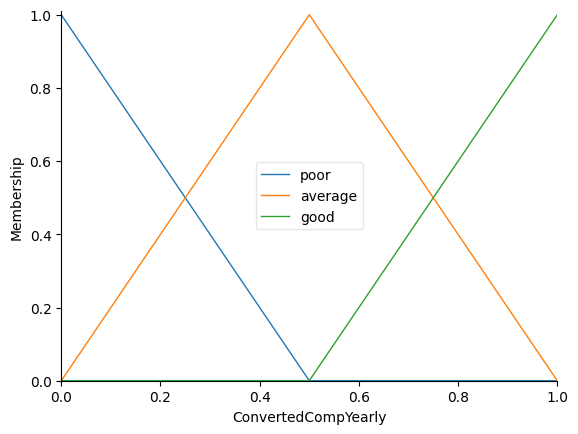

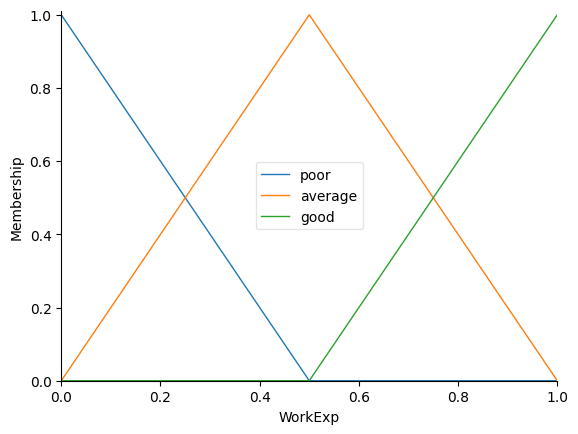

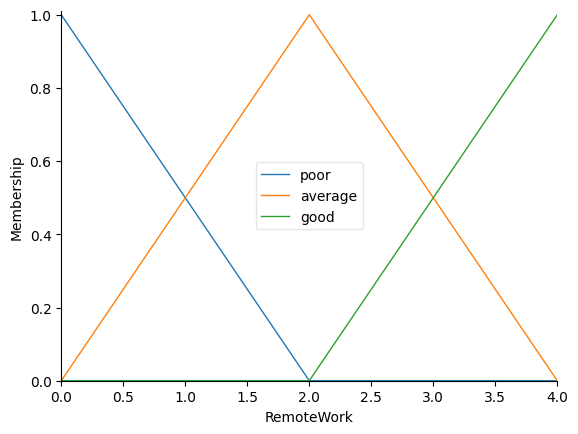

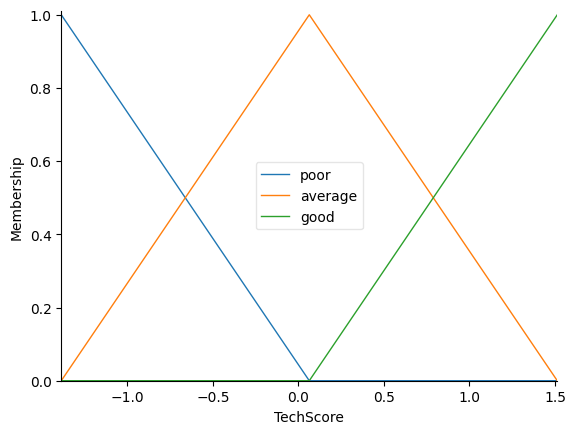

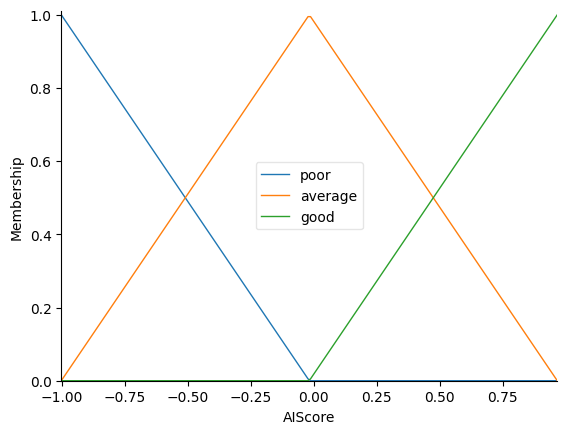

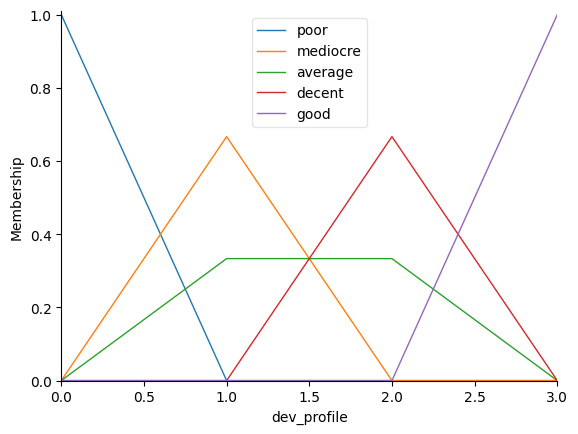

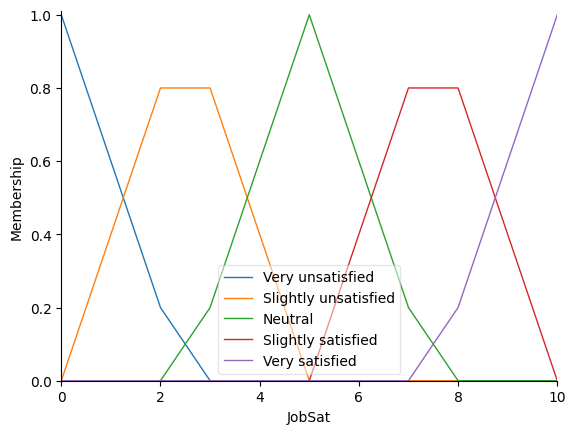

In [50]:
ConvertedCompYearly.view()
WorkExp.view()
RemoteWork.view()
TechScore.view()
AIScore.view()
dev_profile.view()

JobSat.view()

### Define fuzzy rules

### This code defines a set of rules that control how inputs affect the output JobSat

- Each rule connects input conditions to an output level of job satisfaction

In [51]:
rules = [
    ctrl.Rule(ConvertedCompYearly['good'] & WorkExp['good'] & TechScore['good'] & AIScore['good'], JobSat['Very satisfied']),
    ctrl.Rule(WorkExp['good'] & ConvertedCompYearly['good'] & RemoteWork['good'], JobSat['Very satisfied']),
    ctrl.Rule(dev_profile['good'] & TechScore['good'] & RemoteWork['good'], JobSat['Very satisfied']),

    ctrl.Rule(RemoteWork['good'] & ConvertedCompYearly['average'], JobSat['Slightly satisfied']),
    ctrl.Rule(dev_profile['average'] & TechScore['average'], JobSat['Slightly satisfied']),
    ctrl.Rule(AIScore['good'] & WorkExp['poor'], JobSat['Slightly satisfied']),

    ctrl.Rule(ConvertedCompYearly['average'] & WorkExp['average'] & TechScore['average'], JobSat['Neutral']),
    ctrl.Rule(AIScore['average'] & RemoteWork['average'], JobSat['Neutral']),
    ctrl.Rule(ConvertedCompYearly['good'] & TechScore['poor'], JobSat['Neutral']),

    ctrl.Rule(RemoteWork['poor'] & WorkExp['good'], JobSat['Slightly unsatisfied']),
    ctrl.Rule(ConvertedCompYearly['poor'] & TechScore['average'], JobSat['Slightly unsatisfied']),
    ctrl.Rule(AIScore['poor'] & WorkExp['average'], JobSat['Slightly unsatisfied']),

    ctrl.Rule(ConvertedCompYearly['poor'] & WorkExp['poor'], JobSat['Very unsatisfied']),
    ctrl.Rule(TechScore['poor'] & AIScore['poor'], JobSat['Very unsatisfied']),
    ctrl.Rule(dev_profile['poor'], JobSat['Very unsatisfied']),
]

sat_ctrl = ctrl.ControlSystem(rules)

### fuzzy simulator

In [52]:
leadership_simulator = ctrl.ControlSystemSimulation(sat_ctrl)

### Test case

- This code tests the fuzzy system using one sample from the dataset.

- It feeds the sample values into the fuzzy simulator, computes the predicted job satisfaction score, and then converts the numeric result into a clear and readable label.

In [53]:
sample = df.iloc[10] # constant sample for testing

# Input data to the simulator
leadership_simulator.input['ConvertedCompYearly'] = float(sample.get('ConvertedCompYearly', 5))
leadership_simulator.input['WorkExp'] = float(sample.get('WorkExp', 5))
leadership_simulator.input['RemoteWork'] = float(sample.get('RemoteWork', 5))
leadership_simulator.input['TechScore'] = float(sample.get('TechScore', 5))
leadership_simulator.input['AIScore'] = float(sample.get('AIScore', 5))
leadership_simulator.input['dev_profile'] = float(sample.get('Cluster', 5))

# Compute
leadership_simulator.compute()
pred_score = leadership_simulator.output['JobSat']

def get_label(score):
    if score <= 2:
        return 'Very unsatisfied'
    elif score <= 4:
        return 'Slightly unsatisfied'
    elif score <= 6:
        return 'Neutral'
    elif score <= 8:
        return 'Slightly satisfied'
    else:
        return 'Very satisfied'

pred_label = get_label(pred_score)

print(f"Candidate ID:      {sample.name}")
print(f"Fuzzy Prediction:  {pred_label} ({round(pred_score, 2)})")

Candidate ID:      25
Fuzzy Prediction:  Neutral (5.77)


---

# Task 6: Genetic Algorithm Optimization

### GA Setup & Core Functions

- Give the algorithm access to all 62 features in the dataset and let it decide which ones to keep. Each candidate solution (chromosome) is a binary string where 1 means "use this feature" and 0 means "drop it".

In [54]:
all_features = [col for col in df.columns if col != 'Cluster']
print(f"Total candidate features: {len(all_features)}")
print(all_features)

def create_individual():
    individual = [random.randint(0, 1) for _ in range(len(all_features))]
    while sum(individual) < 2:
        individual[random.randint(0, len(individual) - 1)] = 1
    return individual

Total candidate features: 60
['Age', 'EdLevel', 'WorkExp', 'OrgSize', 'RemoteWork', 'ConvertedCompYearly', 'JobSat', 'Employment_Employed', 'Employment_I prefer not to say', 'Employment_Independent contractor, freelancer, or self-employed', 'Employment_Not employed', 'Employment_Student', 'DevType_AI/ML engineer', 'DevType_Academic researcher', 'DevType_Applied scientist', 'DevType_Architect, software or solutions', 'DevType_Cloud infrastructure engineer', 'DevType_Cybersecurity or InfoSec professional', 'DevType_Data engineer', 'DevType_Data or business analyst', 'DevType_Data scientist', 'DevType_Database administrator or engineer', 'DevType_DevOps engineer or professional', 'DevType_Developer, AI apps or physical AI', 'DevType_Developer, QA or test', 'DevType_Developer, back-end', 'DevType_Developer, desktop or enterprise applications', 'DevType_Developer, embedded applications or devices', 'DevType_Developer, front-end', 'DevType_Developer, full-stack', 'DevType_Developer, game or 

- Evaluates a chromosome by selecting the corresponding features and clustering the data using K-Medoids, then returning the silhouette score as the fitness value. If fewer than two features are selected or an error occurs, it returns 0.

In [55]:
def fitness(chromosome):
    selected = [all_features[i] for i in range(len(chromosome)) if chromosome[i] == 1]
    if len(selected) < 2:
        return 0.0
    try:
        X = df[selected].values
        model = KMedoids(n_clusters=best_k, metric='manhattan', init='random', random_state=42)
        labels = model.fit_predict(X)
        return silhouette_score(X, labels)
    except:
        return 0.0

- Generates an initial population for the genetic algorithm by creating a list of random individuals (chromosomes), each representing a possible feature subset.

In [56]:
def create_population(size=30):
    return [create_individual() for _ in range(size)]

- Picks the stronger candidates to breed from.

In [57]:
def tournament_selection(population, fitnesses, k=3):
    selected_idx = random.sample(range(len(population)), k)
    best_idx = max(selected_idx, key=lambda i: fitnesses[i])
    return population[best_idx]

- Mixes two parents at a random split point to produce two children.

In [58]:
def crossover(parent1, parent2):
    point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

- Randomly flips bits with a 10% chance to keep the search from getting stuck on one solution too early.

In [59]:
def mutate(chromosome, mutation_rate=0.1):
    mutated = chromosome.copy()
    for i in range(len(mutated)):
        if random.random() < mutation_rate:
            mutated[i] = 1 - mutated[i]
    while sum(mutated) < 2:
        mutated[random.randint(0, len(mutated)-1)] = 1
    return mutated

### The Main Loop

- Each generation, we evaluate every chromosome in the population and track the best and average Silhouette Score. The top 2 solutions are carried forward unchanged (elitism), and the rest of the new population is filled by selecting pairs of parents, crossing them over, and applying mutation. This repeats for every generation, gradually pushing the population toward better feature subsets.

In [60]:
def genetic_algorithm(population_size, generations, mutation_rate):
    
    population = create_population(population_size)
    best_fitness_history = []
    avg_fitness_history = []

    print(f"\n{'Generation':>10} | {'Best Silhouette':>15} | {'Avg Silhouette':>14} | {'#Features':>10} | Best Features")
    print("-" * 90)

    for gen in range(generations):
        fitnesses = [fitness(ind) for ind in population]

        best_fitness = max(fitnesses)
        avg_fitness = sum(fitnesses) / len(fitnesses)
        best_idx_gen = fitnesses.index(best_fitness)
        best_chrom_gen = population[best_idx_gen]
        best_feats_gen = [all_features[i] for i in range(len(best_chrom_gen)) if best_chrom_gen[i] == 1]

        best_fitness_history.append(best_fitness)
        avg_fitness_history.append(avg_fitness)

        print(f"{gen:>10} | {best_fitness:>15.4f} | {avg_fitness:>14.4f} | "f"{len(best_feats_gen):>10} | {best_feats_gen}")
        
        # Elitism
        new_population = []
        elite_indices  = sorted(range(len(fitnesses)), key=lambda i: fitnesses[i], reverse=True)[:2]

        for idx in elite_indices:
            new_population.append(population[idx])

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, fitnesses)
            parent2 = tournament_selection(population, fitnesses)
            
            child1, child2 = crossover(parent1, parent2)
            
            child1 = mutate(child1, mutation_rate)
            child2 = mutate(child2, mutation_rate)
            
            new_population.extend([child1, child2])

        population = new_population[:population_size]

    final_fitnesses = [fitness(ind) for ind in population]
    best_idx = final_fitnesses.index(max(final_fitnesses))
    best_individual = population[best_idx]
    best_score = final_fitnesses[best_idx]

    return best_individual, best_score, best_fitness_history, avg_fitness_history

### Results & Baseline Comparison

- We run the GA with a population of 30 over 5 generations, then extract the best feature subset it found. To measure whether the GA actually helped, we compare its Silhouette Score against the baseline which is the score we get when all 62 features are used together. Any improvement above the baseline means the GA successfully identified that some features were adding noise rather than value.

In [61]:
best_individual, best_score, best_history, avg_history = genetic_algorithm (
    population_size=30,
    generations=5,
    mutation_rate=0.1
)
selected_features = [all_features[i] for i in range(len(best_individual)) if best_individual[i] == 1]
dropped_features  = [all_features[i] for i in range(len(best_individual)) if best_individual[i] == 0]

print("\n" + "="*60)
print("BEST FEATURE SUBSET FOUND BY GA")
print("="*60)
print(f"  Total features scanned:  {len(all_features)}")
print(f"  Selected ({len(selected_features)}): {selected_features}")
print(f"  Dropped  ({len(dropped_features)}): {dropped_features}")
print(f"  Best Silhouette Score:   {best_score:.4f}")

baseline_score = silhouette_score(df.drop(columns=['Cluster']).values, Kmedoids_model.labels_)
print("\n" + "="*60)
print("COMPARISON: GA Selection vs All Features")
print("="*60)
print(f"  All features Silhouette: {baseline_score:.4f}")
print(f"  GA selected Silhouette:  {best_score:.4f}")
print(f"  Improvement:             +{best_score - baseline_score:.4f}")
print(f"  Features reduced:        {len(all_features)} → {len(selected_features)}")


Generation | Best Silhouette | Avg Silhouette |  #Features | Best Features
------------------------------------------------------------------------------------------
         0 |          0.3439 |         0.2280 |         27 | ['EdLevel', 'OrgSize', 'Employment_Employed', 'Employment_Not employed', 'Employment_Student', 'DevType_Academic researcher', 'DevType_Cybersecurity or InfoSec professional', 'DevType_Data scientist', 'DevType_DevOps engineer or professional', 'DevType_Developer, AI apps or physical AI', 'DevType_Developer, back-end', 'DevType_Developer, embedded applications or devices', 'DevType_Developer, front-end', 'DevType_Developer, game or graphics', 'DevType_Financial analyst or engineer', 'DevType_Founder, technology or otherwise', 'DevType_Other (please specify):', 'DevType_Senior executive (C-suite, VP, etc.)', 'DevType_Student', 'DevType_Support engineer or analyst', 'DevType_UX, Research Ops or UI design professional', 'Industry_Energy', 'Industry_Fintech', 'Indust

### Visualization

- Tracks how the Silhouette Score improved across generations, with the red line marking the baseline score using all features anything above it means the GA found a better subset.

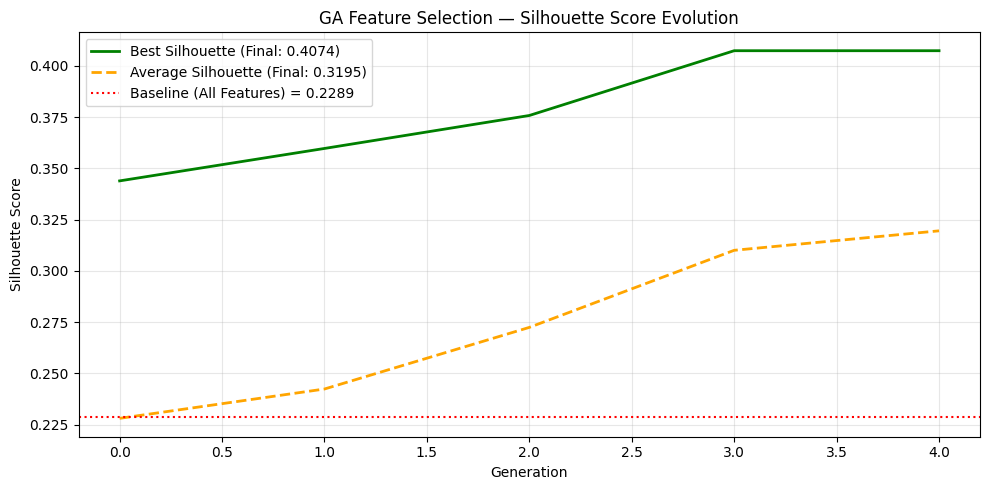

In [62]:
plt.figure(figsize=(10, 5))

final_best = best_history[-1]
final_avg = avg_history[-1]

plt.plot(best_history, label=f'Best Silhouette (Final: {final_best:.4f})',    color='green',  linewidth=2)
plt.plot(avg_history,  label=f'Average Silhouette (Final: {final_avg:.4f})', color='orange', linewidth=2, linestyle='--')
plt.axhline(y=baseline_score, color='red', linestyle=':', linewidth=1.5, label=f'Baseline (All Features) = {baseline_score:.4f}')

plt.title('GA Feature Selection — Silhouette Score Evolution')
plt.xlabel('Generation')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Shows which features were selected and which were dropped (gray), giving a clear picture of what the algorithm decided actually matters for clustering quality.

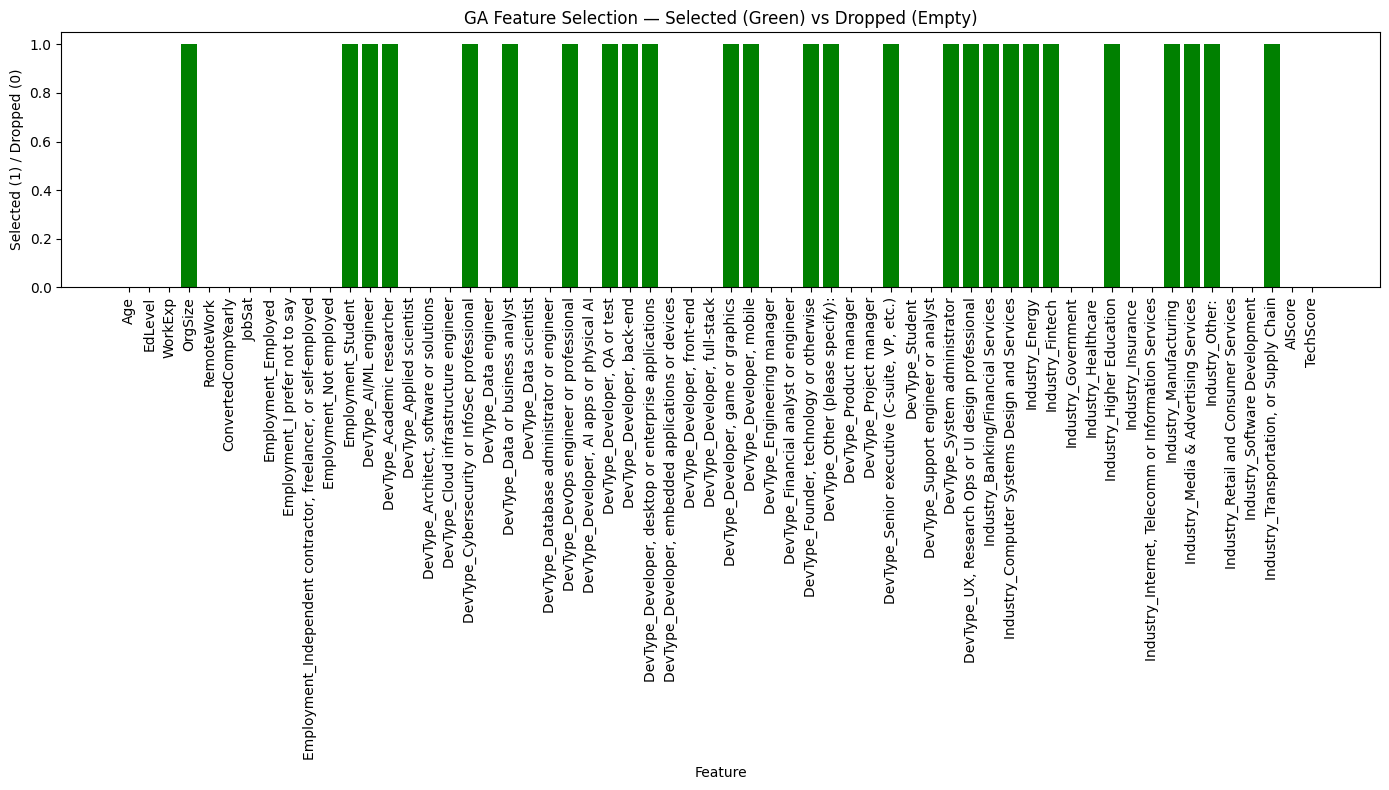

In [63]:
plt.figure(figsize=(14, 8))
colors = ['green' if x == 1 else 'lightgray' for x in best_individual]

plt.bar(all_features, best_individual, color=colors)

plt.title('GA Feature Selection — Selected (Green) vs Dropped (Empty)')
plt.xlabel('Feature')
plt.ylabel('Selected (1) / Dropped (0)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

---

# Task 7: System Implementation

### Flowchart for the pipeline of the project!

![image](flowchart.jpeg)

### The comprehensive implementation

In [64]:
def before_GA(df_sample):
    print("Cluster centers (Before GA): ", Kmedoids_model.medoid_indices_)
    print("Predicted Kmedoids cluster for sample (Before GA): ", Kmedoids_model.predict(df_sample))
    df_sample['Cluster'] = Kmedoids_model.predict(df_sample)
    print("Silhouette Score (Before GA): ", silhouette_score(df.drop(columns=['Cluster']).values, Kmedoids_model.labels_))
    cur = pd.concat([df.drop(columns=['Cluster'], errors='ignore'), df_sample.drop(columns=['Cluster'], errors='ignore')], ignore_index=True)
    for method in ['single', 'complete', 'average']:
        agg_model = AgglomerativeClustering(n_clusters=hbest_k, metric='euclidean', linkage=method)
        all_labels = agg_model.fit_predict(cur)
        sample_label = all_labels[-1]
        print(f"Predicted Agglomerative cluster for sample (Linkage: {method})(Before GA): ", sample_label)


In [65]:
def after_GA(df_sample):
    df_GA = df[selected_features]
    df_sample = df_sample[selected_features]
    new_Kmedoids_model = KMedoids(n_clusters=best_k, metric="manhattan", init="random", random_state=42)
    new_Kmedoids_model.fit(df_GA)
    print("Cluster centers (After GA): ", new_Kmedoids_model.medoid_indices_)
    print("Predicted Kmedoids cluster for sample (After GA): ", new_Kmedoids_model.predict(df_sample))
    df_sample['Cluster'] = new_Kmedoids_model.predict(df_sample)
    print("Silhouette Score (After GA): ", silhouette_score(df_GA.values, new_Kmedoids_model.labels_))
    cur = pd.concat([df_GA.drop(columns=['Cluster'], errors='ignore'), df_sample.drop(columns=['Cluster'], errors='ignore')], ignore_index=True)
    for method in ['single', 'complete', 'average']:
        agg_model = AgglomerativeClustering(n_clusters=hbest_k, metric='euclidean', linkage=method)
        all_labels = agg_model.fit_predict(cur)
        sample_label = all_labels[-1]
        print(f"Predicted Agglomerative cluster for sample (Linkage: {method})(After GA): ", sample_label)

In [66]:
def fuzzyy(df_sample):
    row = df_sample.iloc[0]
    leadership_simulator.input['ConvertedCompYearly'] = float(row.get('ConvertedCompYearly', 2))
    leadership_simulator.input['WorkExp'] = float(row.get('WorkExp', 2))
    leadership_simulator.input['RemoteWork'] = float(row.get('RemoteWork', 2))
    leadership_simulator.input['TechScore'] = float(row.get('TechScore', 2))
    leadership_simulator.input['AIScore'] = float(row.get('AIScore', 2))
    leadership_simulator.input['dev_profile'] = float(row.get('Cluster', 2))
    leadership_simulator.compute()
    pred_score = leadership_simulator.output['JobSat']
    pred_label = get_label(pred_score)
    print(f"Fuzzy Prediction:  {pred_label} ({round(pred_score, 2)})")

In [67]:
def apply_system(df_sample):
    before_GA(df_sample)
    print("-------------------------------------------------------")
    fuzzyy(df_sample)
    print("-------------------------------------------------------")
    after_GA(df_sample)
    

In [68]:
df2_sample = df_sample.copy()
apply_system(df2_sample)

Cluster centers (Before GA):  [3523 1919 7481 6246]
Predicted Kmedoids cluster for sample (Before GA):  [2]
Silhouette Score (Before GA):  0.22890540833801715
Predicted Agglomerative cluster for sample (Linkage: single)(Before GA):  0
Predicted Agglomerative cluster for sample (Linkage: complete)(Before GA):  0
Predicted Agglomerative cluster for sample (Linkage: average)(Before GA):  0
-------------------------------------------------------
Fuzzy Prediction:  Slightly satisfied (6.3)
-------------------------------------------------------
Cluster centers (After GA):  [  51 2516 1606 9569]
Predicted Kmedoids cluster for sample (After GA):  [0]
Silhouette Score (After GA):  0.4589346766842395
Predicted Agglomerative cluster for sample (Linkage: single)(After GA):  0
Predicted Agglomerative cluster for sample (Linkage: complete)(After GA):  1
Predicted Agglomerative cluster for sample (Linkage: average)(After GA):  0


# Part 1: Baseline Analysis (Before Optimization)

- In this first stage, the pipeline evaluates the developer's profile using the full set of available features. We use the pretrained K-Medoids model to find which representative developer (Medoid) best matches our new sample. Since K-Medoids relies on actual data points as cluster centers, this gives us a realistic baseline of the developer’s professional category.

- To ensure the stability of this classification, we also pass the sample through three different Hierarchical (Agglomerative) linkages. This helps us see if the developer clearly belongs to a specific group or if they sit on the "margin" between clusters, where different mathematical methods might disagree on their placement.

# Part 2: Fuzzy Logic Simulation

- Once we have the initial cluster assignment, the pipeline moves to the Fuzzy Inference System. This part of the code acts as the decision maker; it takes the developer’s raw inputs such as their salary, years of experience, and remote work status and maps them against our defined expert rules.

- Instead of a simple "yes/no" classification, the fuzzy simulator calculates a precise Job Satisfaction score. This score accounts for the nuance in human feelings toward work, finally translating the numerical output into a readable label like "Satisfied," "Neutral," or "Dissatisfied."

# Part 3: Post-GA Refinement (The Optimized View)

- The final stage of the pipeline demonstrates the impact of our Genetic Algorithm . By rerunning the clustering process using only the feature subset selected by the GA, we strip away the "noise" that might have blurred the initial analysis.

- Because the feature space has changed, the model identifies a new set of representative Medoids that better capture the core differences between developers. This often leads to a more accurate classification, as the models can now focus on the metrics that truly define a developer’s professional profile. Comparing this "After GA" result with the baseline helps us see how much more reliable our predictions become when we focus on the most important data.